# Лабораторная 5

In [1]:
from ultralytics import YOLO
import torch

##### Чтобы модель могла распознавать и буквы и цифры (как нужно по заданию), я сделал смешанный датасет из SVHN и COCO-Text

### Обучите (или дообучите) нейронную сеть детектировать номера на изображениях (номер представляет собой последовательность длиной до 20 символов из цифр, прописных и строчных букв русского или английского алфавита, знаков дефис и слеш).

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"{device}")

cuda


#### Выбрал модель Yolo Nano, так как она достаточно просто инициализируется и более легкая чем East

In [3]:
model = YOLO('yolov8n.pt')

results = model.train(
    data='uni_dataset/data.yaml',
    epochs=40,
    imgsz=640,
    batch=16,
    name='yolov8_text_detection',
    freeze=10
)

New https://pypi.org/project/ultralytics/8.4.33 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.32  Python-3.13.5 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3070 Ti Laptop GPU, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=uni_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name

### Оценка качества детекции производится с помощью метрик IoU, Precision, Recall, mAP на тестовой части набора The Street View House Numbers http://ufldl.stanford.edu/housenumbers/. Требуется mAP не менее 0,6

In [7]:
test_yaml = """
train: test
val: test
nc: 1
names: ['text']
"""

with open("test_data.yaml", "w") as f:
    f.write(test_yaml)

best_model = YOLO('runs/detect/yolov8_text_detection/weights/best.pt')

print("Валидация на тестовой выборке SVHN")
metrics = best_model.val(data='test_data.yaml', split='val')

print(f"mAP@50: {metrics.box.map50:.3f}")
print(f"mAP@50-95: {metrics.box.map:.3f}")

Валидация на тестовой выборке SVHN
Ultralytics 8.4.32  Python-3.13.5 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3070 Ti Laptop GPU, 8192MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.20.0 ms, read: 46.875.4 MB/s, size: 15.3 KB)
val: Scanning C:\Users\gerta\PycharmProjects\cv-labs\lab5\test.cache... 13068 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 13068/13068 97.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 817/817 13.0it/s 1:03<0.2ss
                   all      13068      13068      0.875      0.845      0.886      0.505
Speed: 0.5ms preprocess, 1.5ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to C:\Users\gerta\PycharmProjects\cv-labs\lab5\runs\detect\val2
mAP@50: 0.886
mAP@50-95: 0.505


##### Precision = 0.88
##### Recall = 0.85
##### map50 = 0.89 > 0.6

### Сфотографируйте номера на улицах города (не из Интернета, проверим поиском по картинке) и запустите на них свой алгоритм.


0: 640x640 16 texts, 38.0ms
1: 640x640 2 texts, 38.0ms
2: 640x640 1 text, 38.0ms
3: 640x640 3 texts, 38.0ms
4: 640x640 4 texts, 38.0ms
5: 640x640 7 texts, 38.0ms
6: 640x640 5 texts, 38.0ms
Speed: 5.3ms preprocess, 38.0ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


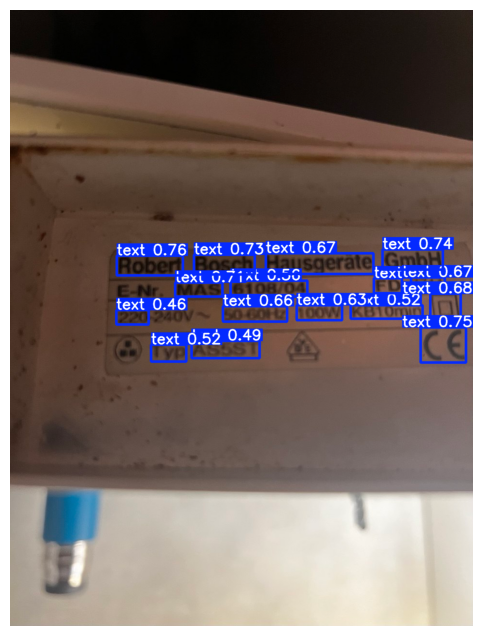

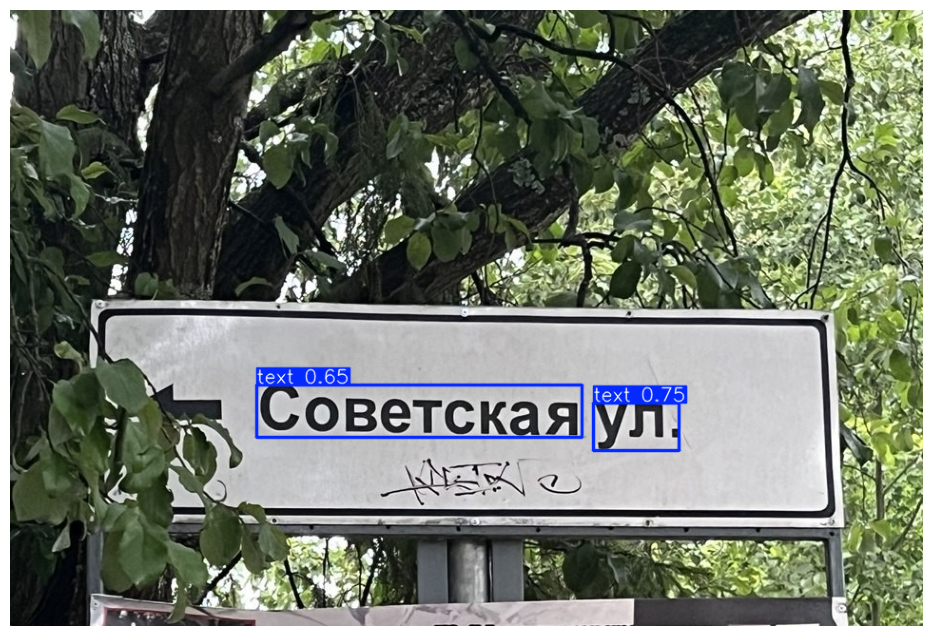

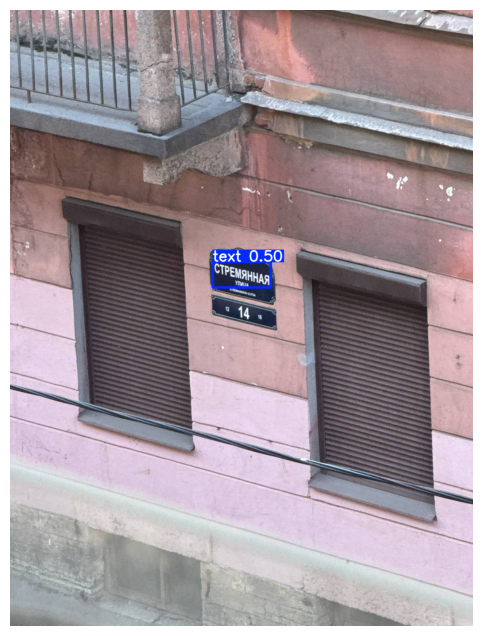

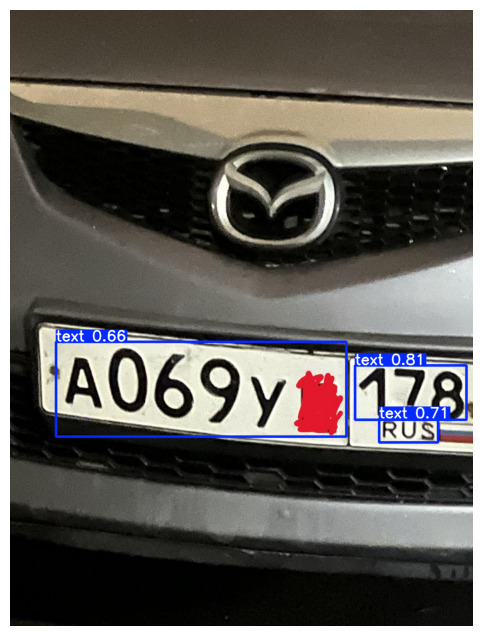

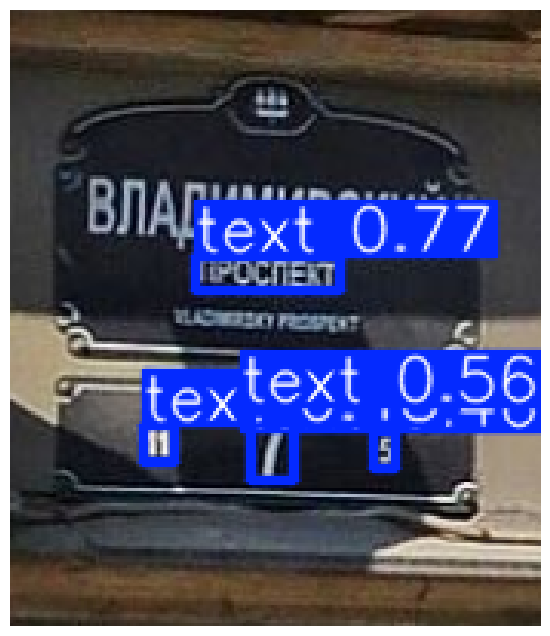

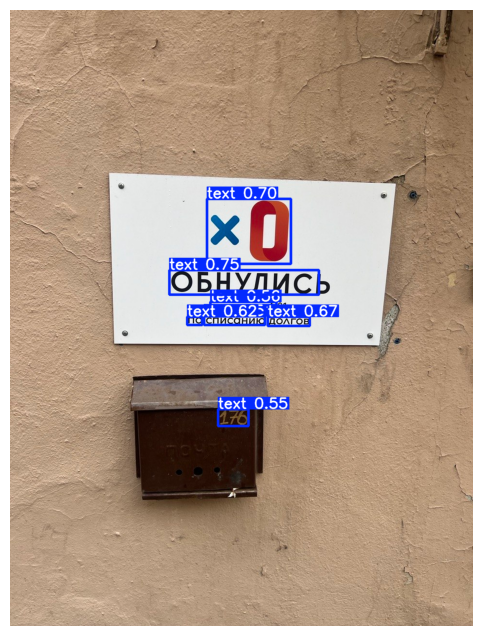

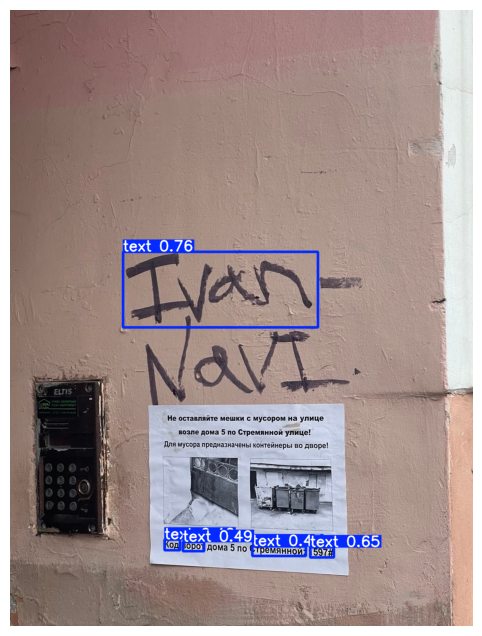

In [8]:
%matplotlib inline
import cv2
import matplotlib.pyplot as plt
import glob

model = YOLO('runs/detect/yolov8_text_detection/weights/best.pt')

photo_paths = glob.glob('my_photos/*.*')
photo_paths = [p for p in photo_paths if p.lower().endswith(('.png', '.jpg', '.jpeg'))]

results = model.predict(source=photo_paths, conf= 0.45, iou=0.4)

for i, r in enumerate(results):
    im_bgr = r.plot()
    im_rgb = cv2.cvtColor(im_bgr, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 8))
    plt.imshow(im_rgb)
    plt.axis('off')
    plt.show()